In [55]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config, apply_experiment_id_to_paths
from src.mgf_dataset import create_mgf_dataset
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer

# Compute likelihood of test theta values based on training distribution
from scipy.stats import lognorm
import numpy as np

# Load config and resolve experiment paths
cfg = load_full_config()
apply_experiment_id_to_paths(cfg)

mode = cfg.get('mode', 'standard_ou')
save_dir = os.path.join('..', cfg.get('paths', {}).get('save_dir', 'experiments'))
results_base = cfg.get('paths', {}).get('predictive_test_results_name', 'predictive_test_results.csv')

print(f"Mode: {mode}")
print(f"Results dir: {save_dir}")
print(f"Results base name: {results_base}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Mode: binary_ou_observed
Results dir: ../experiments
Results base name: predictive_test_results.csv


In [56]:
import pandas as pd

# Build coef0 results path from config base name
name_parts = results_base.rsplit(".", 1)
coef0_name = f"{name_parts[0]}_coef0.{name_parts[1]}" if len(name_parts) == 2 else f"{results_base}_coef0"
results_path = os.path.join(save_dir, coef0_name)

print(f"Loading: {results_path}")
results_df = pd.read_csv(results_path)

Loading: ../experiments/predictive_test_results_coef0.csv


In [57]:
lengths = results_df.sequence_length.unique()
lengths
results_df

,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,0.000302,0.000191,0.000493,0.728798,0.043857,0.772656,5000
1,theta_sweeps,5,0.2625,0.000308,0.000616,0.000924,0.742654,0.048744,0.791398,5000
2,theta_sweeps,5,0.4250,0.000187,0.000465,0.000652,0.762283,0.053625,0.815908,5000
3,theta_sweeps,5,0.5875,0.000069,0.000241,0.000310,0.759095,0.059855,0.818950,5000
4,theta_sweeps,5,0.7500,0.000005,0.000333,0.000338,0.778514,0.073604,0.852118,5000
...,...,...,...,...,...,...,...,...,...,...
220,theta_sweeps,400,3.3500,0.040240,92.451645,92.491885,0.559603,186.281998,186.841600,5000
221,theta_sweeps,400,3.5125,0.005870,20.515547,20.521417,1.066075,33.247879,34.313954,5000
222,theta_sweeps,400,3.6750,0.107004,567.549500,567.656503,1.650552,721.651917,723.302468,5000
223,theta_sweeps,400,3.8375,0.154145,256.819763,256.973909,0.684661,210.963928,211.648589,5000


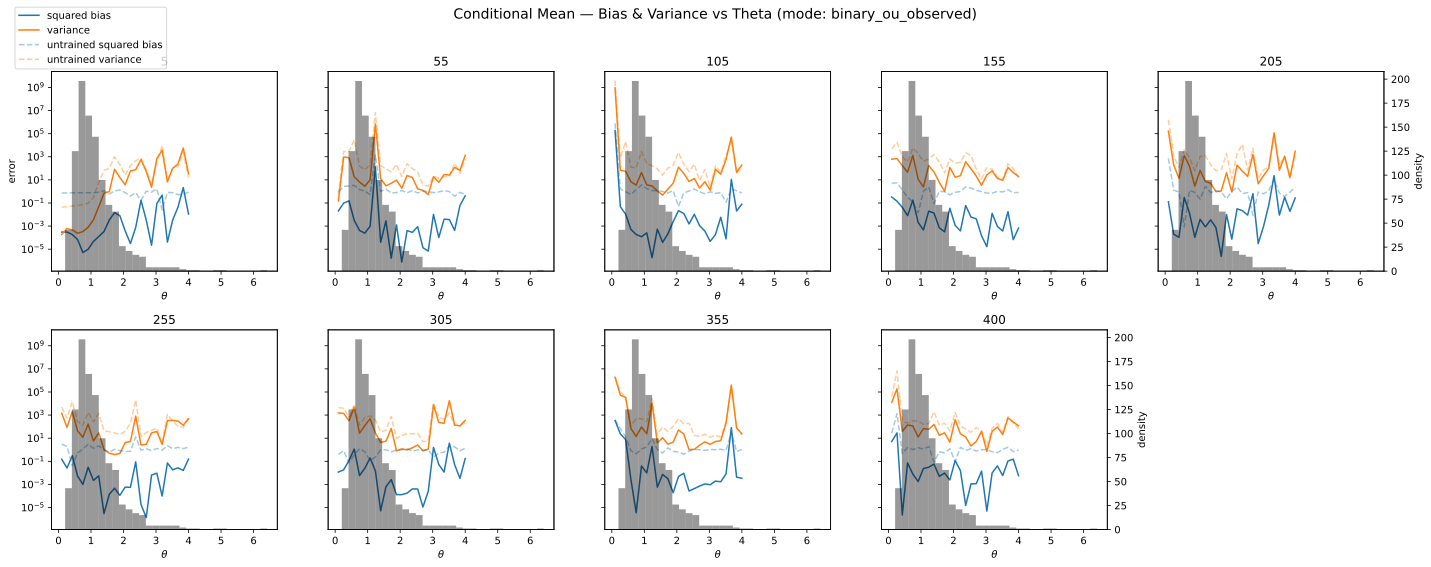

In [58]:
data_path = os.path.join('..', cfg['paths']['mgf_data_path'])
data = torch.load(data_path, weights_only=False)
training_thetas = data['theta_values'].numpy()

nrows = 2
ncols = int(np.ceil(len(lengths) / nrows))
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 8), sharey=True)
axs = np.atleast_1d(axs).ravel()
fig.suptitle(f"Conditional Mean — Bias & Variance vs Theta (mode: {mode})", fontsize=14)

legend_handles, legend_labels = None, None

for i, length in enumerate(lengths):
    ax = axs[i]
    ax.set_title(f"{length}")
    df = results_df[results_df.sequence_length == length]
    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()
    ax.plot(theta, bias, "C0", label="squared bias")
    ax.semilogy(theta, variance, "C1", label="variance")
    ax.plot(theta, ut_bias, "C0--", label="untrained squared bias", alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance", alpha=0.4)

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.set_xlabel(r"$\theta$")
    if i == 0:
        ax.set_ylabel("error")
    axt = ax.twinx()
    axt.hist(training_thetas, 30, color="k", alpha=0.4)
    if i % ncols == ncols - 1 or i == len(lengths) - 1:
        axt.set_ylabel("density")
    else:
        axt.set_yticks([])

for j in range(len(lengths), len(axs)):
    axs[j].set_visible(False)

if legend_handles is not None:
    fig.legend(legend_handles, legend_labels, loc="upper left", bbox_to_anchor=(0.01, 0.99))

plt.tight_layout(rect=[0, 0, 1, 0.96])

In [59]:
# Load variance prediction results (coefficient 1)
coef1_name = f"{name_parts[0]}_coef1.{name_parts[1]}" if len(name_parts) == 2 else f"{results_base}_coef1"
variance_results_path = os.path.join(save_dir, coef1_name)

print(f"Loading: {variance_results_path}")
variance_results_df = pd.read_csv(variance_results_path)

print(f"Variance prediction results shape: {variance_results_df.shape}")
variance_results_df.head()

Loading: ../experiments/predictive_test_results_coef1.csv
Variance prediction results shape: (225, 10)


,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,438.625420,6.968106,445.593527,9365.792242,2129.912842,11495.705084,5000
1,theta_sweeps,5,0.2625,39.525028,2.572266,42.097294,712.220009,308.374756,1020.594765,5000
2,theta_sweeps,5,0.4250,9.003528,0.837898,9.841426,171.544802,102.347466,273.892268,5000
3,theta_sweeps,5,0.5875,2.650485,0.380800,3.031284,61.131262,50.521667,111.652929,5000
4,theta_sweeps,5,0.7500,0.769340,0.218926,0.988266,24.273417,26.870731,51.144148,5000


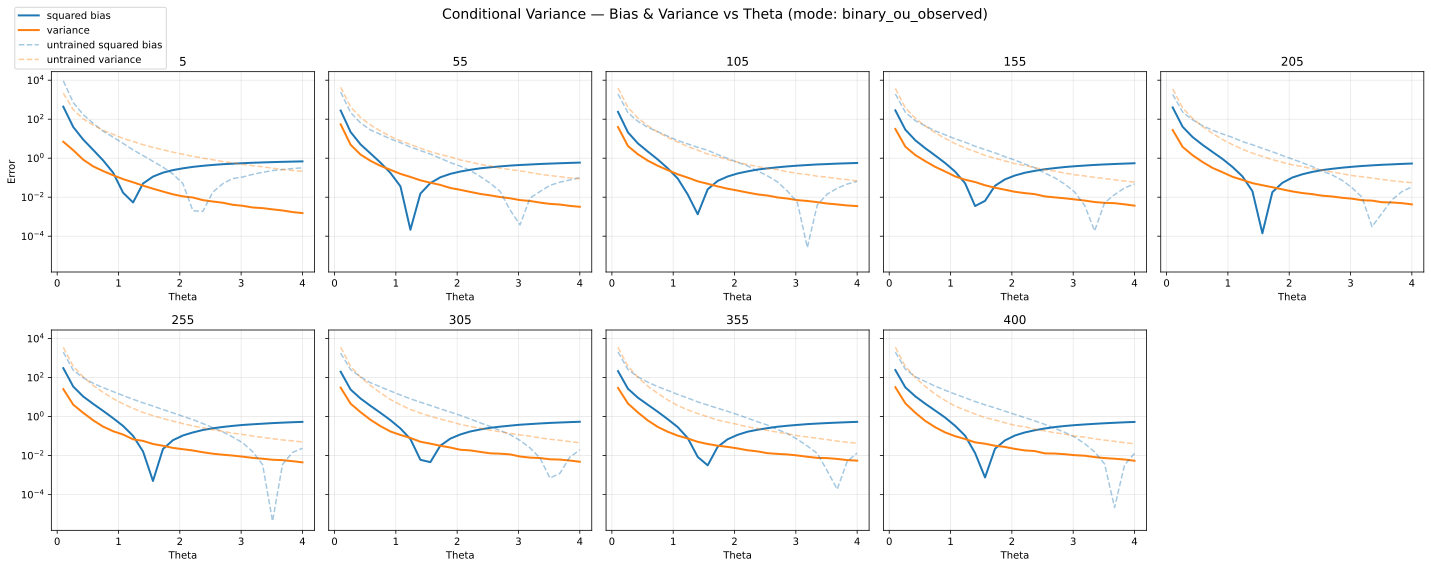

In [60]:
# Plot bias and variance vs theta for different sequence lengths (Variance Prediction)
lengths_var = variance_results_df.sequence_length.unique()

nrows = 2
ncols = int(np.ceil(len(lengths_var) / nrows))
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 8), sharey=True)
axs = np.atleast_1d(axs).ravel()
fig.suptitle(f"Conditional Variance — Bias & Variance vs Theta (mode: {mode})", fontsize=14)

legend_handles, legend_labels = None, None

for i, length in enumerate(lengths_var):
    ax = axs[i]
    ax.set_title(f"{length}")
    df = variance_results_df[variance_results_df.sequence_length == length]

    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()

    ax.plot(theta, bias, "C0", label="squared bias", linewidth=2)
    ax.semilogy(theta, variance, "C1", label="variance", linewidth=2)
    ax.plot(theta, ut_bias, "C0--", label="untrained squared bias", alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance", alpha=0.4)

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.set_xlabel("Theta")
    if i == 0:
        ax.set_ylabel("Error")
    ax.grid(True, alpha=0.3)

for j in range(len(lengths_var), len(axs)):
    axs[j].set_visible(False)

if legend_handles is not None:
    fig.legend(legend_handles, legend_labels, loc="upper left", bbox_to_anchor=(0.01, 0.99))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()